[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/darkmetrics/CarryTrade/blob/main/carry_trade.ipynb)

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from typing import Union

In [7]:
fx = pd.read_excel('data/clean_data.xlsx', sheet_name='fx')
vol = pd.read_excel('data/clean_data.xlsx', sheet_name='volatility')

In [8]:
fx.fillna(method='ffill', inplace=True)

C:\Users\Carrey Chen\AppData\Local\Temp\ipykernel_33936\381466298.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  fx.fillna(method='ffill', inplace=True)


In [9]:
fx.index = pd.to_datetime(fx.date)
vol.index = pd.to_datetime(vol.date)
fx.drop(columns='date', inplace=True)
vol.drop(columns='date', inplace=True)

Now:

We will select only the mid price for spot and forward quotes, since everything else is needed only for calculating transaction costs. These costs are small, and at the initial stage we can safely ignore them without materially affecting the results.

We will rename the columns to make them easier to work with: forward quotes will be named as “currency name” + “1m”.

In [10]:
mid_cols = [x for x in fx.columns if 'mid' in x]
fx = fx[mid_cols]
new_colnames = [x.replace('_fwd_mid', '1m') if '_fwd_mid' in x \
                else x.replace('_mid', '') for x in fx.columns]
fx.columns = new_colnames
fx.head(5)

,EUR,EUR1m,AUD,AUD1m,CAD,CAD1m,CHF,CHF1m,GBP,GBP1m,JPY,JPY1m,NOK,NOK1m,NZD,NZD1m,SEK,SEK1m
date,,,,,,,,,,,,,,,,,,
1996-12-31,1.53870,-31.20,0.79415,-3.827,1.37050,-29.739,1.34150,-42.396,1.71400,-11.0,115.700,-49.812,6.37745,-98.0,0.70675,-13.75,6.81220,-89.5
1997-01-01,1.53905,-31.50,0.79455,-3.300,1.37045,-27.750,1.34125,-43.000,1.71150,-10.5,115.885,-51.000,6.37765,-98.0,0.70595,-13.50,6.80735,-87.5
1997-01-02,1.54175,-31.50,0.79105,-3.600,1.37595,-28.376,1.34845,-42.616,1.69390,-10.5,115.675,-50.500,6.38175,-95.0,0.70765,-13.75,6.87510,-8.0
1997-01-03,1.56745,-30.95,0.79045,-3.386,1.37025,-27.249,1.35950,-42.555,1.68730,-10.6,116.435,-50.500,6.48370,-102.0,0.70685,-14.00,6.96205,-93.0
1997-01-06,1.56585,-32.25,0.78935,-3.654,1.36555,-27.704,1.35300,-44.637,1.69635,-11.5,115.745,-51.000,6.46555,-115.0,0.70915,-12.75,6.94660,-93.5


Now we will convert the forward quotes into a more convenient format. For all currencies except the yen, we will divide the forward price by 10,000 (for the yen — by 100) and then add this value to the corresponding spot price.

In [11]:
spot_no_jpy = [x for x in fx.columns if '1m' not in x and 'JPY' not in x]
for ticker in spot_no_jpy:
    fx[f"{ticker}1m"]=fx[ticker]+fx[f"{ticker}1m"]/10_000
fx['JPY1m']=fx['JPY']+fx['JPY1m']/100
fx.head(5)

,EUR,EUR1m,AUD,AUD1m,CAD,CAD1m,CHF,CHF1m,GBP,GBP1m,JPY,JPY1m,NOK,NOK1m,NZD,NZD1m,SEK,SEK1m
date,,,,,,,,,,,,,,,,,,
1996-12-31,1.53870,1.535580,0.79415,0.793767,1.37050,1.367526,1.34150,1.337260,1.71400,1.71290,115.700,115.20188,6.37745,6.36765,0.70675,0.705375,6.81220,6.80325
1997-01-01,1.53905,1.535900,0.79455,0.794220,1.37045,1.367675,1.34125,1.336950,1.71150,1.71045,115.885,115.37500,6.37765,6.36785,0.70595,0.704600,6.80735,6.79860
1997-01-02,1.54175,1.538600,0.79105,0.790690,1.37595,1.373112,1.34845,1.344188,1.69390,1.69285,115.675,115.17000,6.38175,6.37225,0.70765,0.706275,6.87510,6.87430
1997-01-03,1.56745,1.564355,0.79045,0.790111,1.37025,1.367525,1.35950,1.355244,1.68730,1.68624,116.435,115.93000,6.48370,6.47350,0.70685,0.705450,6.96205,6.95275
1997-01-06,1.56585,1.562625,0.78935,0.788985,1.36555,1.362780,1.35300,1.348536,1.69635,1.69520,115.745,115.23500,6.46555,6.45405,0.70915,0.707875,6.94660,6.93725


Finally, we will convert all spot and forward quotes to a unified format: 1 USD per 1 unit of the currency. To do this, we will raise certain columns to the power of −1.
* EUR
* AUD
* GBP
* NZD

In [12]:
invert = [x for x in fx.columns if \
          any(y in x for y in['EUR', 'AUD', 'GBP', 'NZD'])]
invert
for x in invert:
    fx[x] = 1/fx[x]

C:\Users\Carrey Chen\AppData\Local\Temp\ipykernel_33936\2691227507.py:29: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


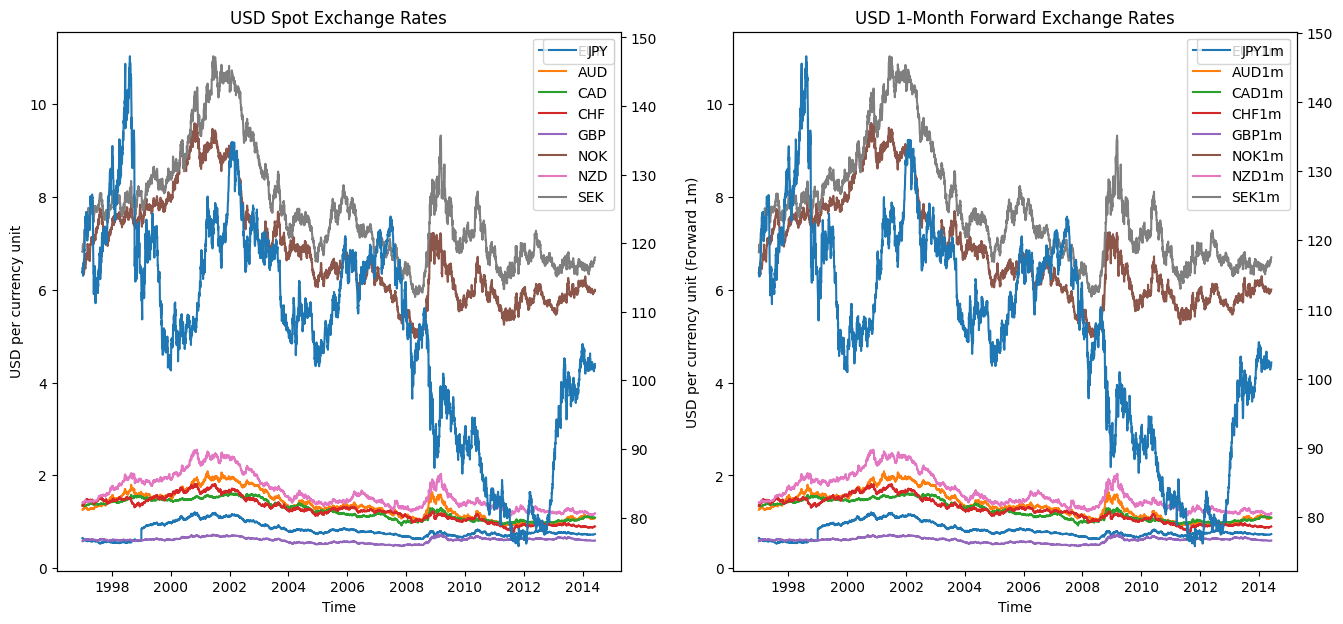

In [13]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(16, 7))

# --- Spot rates ---
ax2 = ax[0].twinx()
for ticker in spot_no_jpy:
    ax[0].plot(fx.index, fx[ticker], label=ticker)
ax2.plot(fx.index, fx.JPY, label='JPY')

ax[0].legend()
ax2.legend()

ax[0].set_xlabel('Time')
ax[0].set_ylabel('USD per currency unit')
ax[0].set_title('USD Spot Exchange Rates')

# --- Forward rates ---
ax3 = ax[1].twinx()
for ticker in [x + '1m' for x in spot_no_jpy]:
    ax[1].plot(fx.index, fx[ticker], label=ticker)
ax3.plot(fx.index, fx.JPY1m, label='JPY1m')

ax[1].legend()
ax3.legend()

ax[1].set_xlabel('Time')
ax[1].set_ylabel('USD per currency unit (Forward 1m)')
ax[1].set_title('USD 1-Month Forward Exchange Rates')

fig.show()


Since these plots are not very informative, we will instead plot the forward premium (in percentage terms) for each currency in the sample.

C:\Users\Carrey Chen\AppData\Local\Temp\ipykernel_33936\3671769792.py:15: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


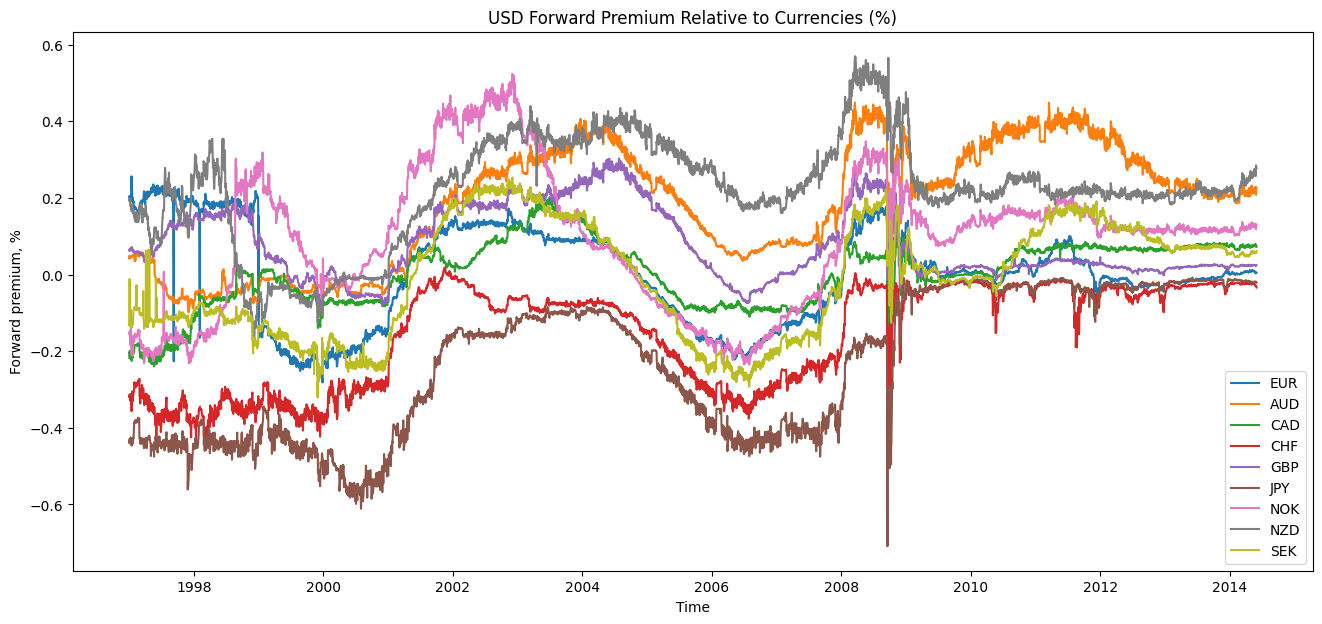

In [14]:
fig, ax = plt.subplots(figsize=(16, 7))

for ticker in [x for x in fx.columns if '1m' not in x]:
    ax.plot(
        fx.index,
        (fx[f"{ticker}1m"] - fx[ticker]) / fx[ticker] * 100,
        label=ticker
    )

ax.legend()
ax.set_xlabel('Time')
ax.set_ylabel('Forward premium, %')
ax.set_title('USD Forward Premium Relative to Currencies (%)')

fig.show()

This plot is much more informative. We can see that the Australian dollar (orange) and the New Zealand dollar (gray) mostly traded at a forward premium, while the yen and the Swiss franc (brown and red) traded at a discount. This is consistent with what the authors describe and is also quite intuitive: since the early 2000s, Japan has pursued a zero interest rate policy (ZIRP), so Japanese interest rates were lower than U.S. rates. As a result, the forward JPY/USD rate should embed an expected depreciation of the dollar against the yen.

We can also see that after the 2008 crisis, interest rates fell across all G10 countries as part of accommodative monetary policy. This is clearly reflected in the decline of forward premiums and discounts in the plot.

Now we will plot the volatility index data.

C:\Users\Carrey Chen\AppData\Local\Temp\ipykernel_33936\1770523429.py:14: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


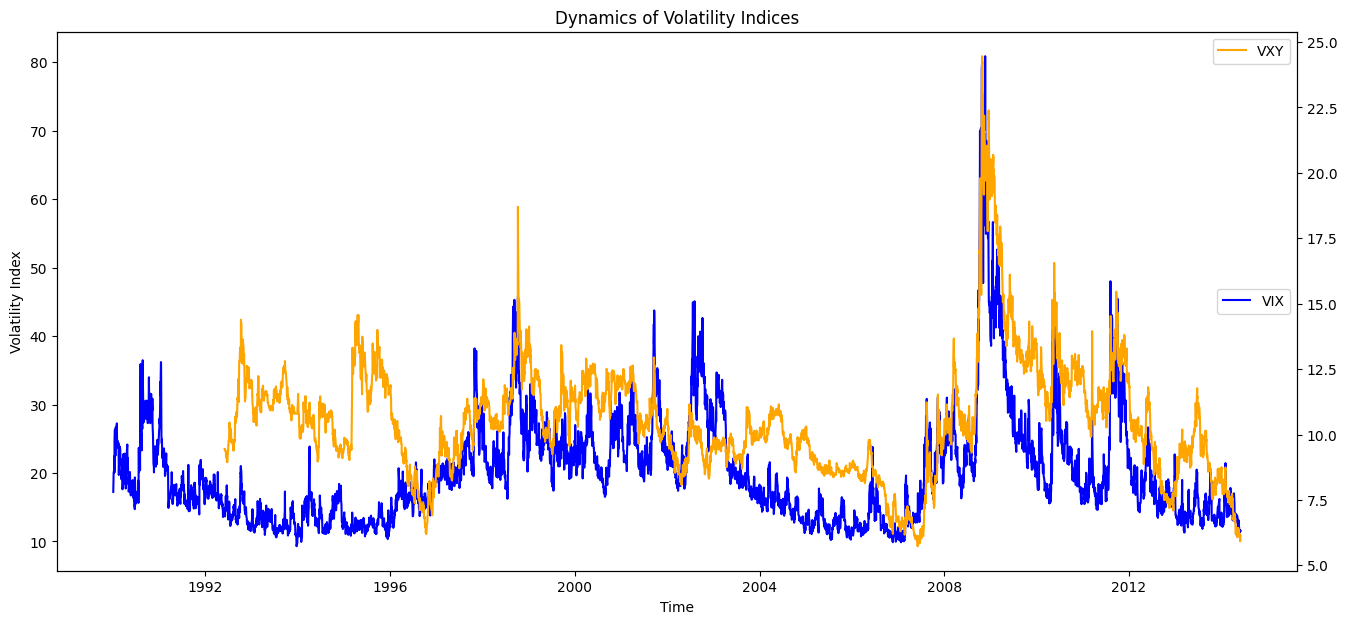

In [15]:
fig, ax = plt.subplots(figsize=(16, 7))

ax2 = ax.twinx()
ax.plot(vol.index, vol.VIX, label='VIX', color='blue')
ax2.plot(vol.index, vol.VXY, label='VXY', color='orange')

ax.legend(loc='center right')
ax2.legend()

ax.set_xlabel('Time')
ax.set_ylabel('Volatility Index')
ax.set_title('Dynamics of Volatility Indices')

fig.show()

С предобработкой данных закончено, можно сохранять датасет.

In [16]:
fx.to_csv('data/fx.csv')
vol.to_csv('data/vol.csv')

### 2. Carry Trade.

In [17]:
fx.head()

,EUR,EUR1m,AUD,AUD1m,CAD,CAD1m,CHF,CHF1m,GBP,GBP1m,JPY,JPY1m,NOK,NOK1m,NZD,NZD1m,SEK,SEK1m
date,,,,,,,,,,,,,,,,,,
1996-12-31,0.649899,0.651220,1.259208,1.259815,1.37050,1.367526,1.34150,1.337260,0.583431,0.583805,115.700,115.20188,6.37745,6.36765,1.414927,1.417686,6.81220,6.80325
1997-01-01,0.649751,0.651084,1.258574,1.259097,1.37045,1.367675,1.34125,1.336950,0.584283,0.584641,115.885,115.37500,6.37765,6.36785,1.416531,1.419245,6.80735,6.79860
1997-01-02,0.648614,0.649942,1.264143,1.264718,1.37595,1.373112,1.34845,1.344188,0.590354,0.590720,115.675,115.17000,6.38175,6.37225,1.413128,1.415879,6.87510,6.87430
1997-01-03,0.637979,0.639241,1.265102,1.265644,1.37025,1.367525,1.35950,1.355244,0.592663,0.593035,116.435,115.93000,6.48370,6.47350,1.414727,1.417535,6.96205,6.95275
1997-01-06,0.638631,0.639949,1.266865,1.267452,1.36555,1.362780,1.35300,1.348536,0.589501,0.589901,115.745,115.23500,6.46555,6.45405,1.410139,1.412679,6.94660,6.93725


When computing the quantile of the volatility index distribution, I used the nearest method. This means that no interpolation is performed; instead, the value in the sample that is closest to the desired quantile is selected. It’s possible that this parameter could be adjusted, but given the large number of observations in the sample, I don’t expect the choice of quantile calculation method to have any meaningful impact on the resulting quantile values of the empirical distribution.

In [19]:
class CarryTrade:
    def __init__(self, 
                 fx:pd.DataFrame, 
                 vol:Union[pd.Series, None]=None):
        """
        Class constructor. 
        
        Parameters:
        -----------
        fx: pd.DataFrame with spot and forward FX prices. Forward FX
            columns should contain '1m' in column names. For each currency
            in the dataset there should be both spot and forward column.
            Number of currencies can not be less than n_trade * 2.
        vol: pd.Series, default None. pd.Series with historical values
            for some volatility index.
        """
        self.fx = fx
        # it's important to drop na because np.percentile treats na as infty
        if vol is not None:
            self.vol = vol.dropna()
        # empty attributes for future data
        self.vol_data = None
        self.carry_returns = None
        self.strategy_returns = None
    
    def run(self, 
            n_trade:int=3,
            use_vol:bool=False,
            vol_type:str='simple',
            vol_quantile:float=0.95,
            quantile_method:str='nearest',
            vol_lag:int=1,
            refit:bool=True,
            ma_window:int=5):
        """
        Method to run strategy on data from self.fx and self.vol
        
        Parameters:
        -----------
        n_trade:int, default 3 (as in article). Number of currency pairs
            to long and to short.    
        use_vol: bool, default False. Whether to use volatility data when
            running strategy or not.
        vol_type: str, default 'simple'. Possible values: 'simple', 'averaged' 
            or 'smoothed'. Depends on the volatility signal methodology 
            calculation (simple, averaged by 60 days or our custom smoothed method, 
            for details study the paper).
        vol_quantile:float, default None. The percentile of empirical
            volatility indicator distribution to use when calculating 
            "signal" for trading strategy (whether to trade or not).
        quantile_method: str, default 'nearest'. Possible values: 'linear', 
            'lower', 'higher', 'midpoint', 'nearest'. Empirical quantile 
            calculation method for np.percentile for volatility index.
        vol_lag: int, default 1. How many periods to shift volatility indicator
            ahead to use lags of volatility when calculating "signal".
        refit: bool, default True. Whether to run not only volatility estimation
            and carry trade with volatility, but also simple carry strategy when 
            simple carry trade has already been estimated before (attribute 
            carry_returns is not empty).
        ma_window:int, default 5. Number of trading days to smooth volatility 
            value compared with index percentile. Used when 'vol_type'='smoothed'.
        """
        
        # names for forward, spot and forward premium columns
        spot_cols = [x for x in self.fx.columns if '1m' not in x]
        fwd_cols = [x for x in self.fx.columns if '1m' in x]
        prem_cols = [x+'_premium' for x in spot_cols]
        ret_cols = [x+'_ret' for x in spot_cols]
        pos_cols = [x+'_pos' for x in spot_cols]
        
        if refit:
            # calculate spot returns and forward premiums 
            for x in spot_cols:
                self.fx[f'{x}_ret']=self.fx[x].pct_change()
                self.fx[f'{x}_premium']=(self.fx[f'{x}1m'] - self.fx[x])/self.fx[x]
                
        
            # shift premium column data 1 day ahead
            # to use forward data from day t_1 to trade in day t
            self.fx[prem_cols].shift(1)
            self.fx.dropna(inplace=True)
            
            # transform data to dict to make strategy faster
            fx_dict = self.fx[prem_cols].to_dict(orient='index')
            position_dict = {}
            
            # find tickers with n_trade highest forward premiums
            # and n_trade lowest forward premiums for each date
            for time, data in fx_dict.items():
                sorted_data = {k: v for k, v in \
                               sorted(data.items(), key=lambda item:item[1])}
                
                sorted_tickers = list(sorted_data.keys())
                # short tickers with highest premium (lowest discount)
                short_tickers = [x.split('_')[0] for x in sorted_tickers[-n_trade:]]
                # long tickers with lowest premium (highest discount)
                long_tickers = [x.split('_')[0] for x in sorted_tickers[0:n_trade]]
    
                # add positions to position dict
                position_dict[time]={(k+"_pos"):1 if k in long_tickers else \
                                     (-1 if k in short_tickers else 0) \
                                     for k in spot_cols}
        
            position_df = pd.DataFrame(position_dict).T
            self.fx = pd.merge(left=position_df, right=self.fx, 
                               left_index=True,
                               right_index=True)
            # calculate total strategy returns
            self.fx['carry_returns']=( (self.fx[pos_cols].div(n_trade)).values * \
                                         (self.fx[ret_cols]).values ).sum(axis=1)
            self.carry_returns = self.fx['carry_returns']
        
        # take into account volatility
        if use_vol:
            if vol_type=='simple':
                # calculate volatility percentiles and threshold
                self.simple_vol(vol_quantile, quantile_method, vol_lag)
            elif vol_type=='averaged':
                # calculate volatility percentiles and threshold
                self.averaged_vol(vol_quantile, quantile_method, vol_lag)     
            elif vol_type=='smoothed':
                # calculate volatility percentiles and threshold
                self.smoothed_vol(vol_quantile, quantile_method, vol_lag, ma_window)
                
            self.fx['strategy_returns'] = self.fx['carry_returns'] * \
                                         self.vol_data['signal']
            self.fx.dropna(inplace=True)
            self.strategy_returns = self.fx['strategy_returns']
            
    
    def simple_vol(self,
                   vol_quantile:float=0.95,
                   quantile_method:str='nearest',
                   vol_lag:int=1):
        """
        Estimate simple rolling volatility percentile
        """
        # get volatility index name
        vol_index = self.vol.name
        # calculate expanding window volatility percentile
        percentile = self.vol.expanding().apply(lambda x: \
                                     np.quantile(x, 
                                                 q=vol_quantile, 
                                                 interpolation=quantile_method))
        percentile.name='threshold'
        # shift (or not shift) volatility data to decide whether 
        # to trade or not in day t based on volatility data from t-1
        self.vol_data = pd.concat([self.vol.shift(vol_lag), 
                                   percentile.shift(vol_lag)], 
                                   axis=1)
        
        # add missing dates to self.vol_data from self.fx
        new_index = self.fx.index
        self.vol_data = self.vol_data.reindex(new_index, method='ffill')
        # drop unnecessary dates from 1990 to 1996
        self.vol_data = self.vol_data.loc[new_index]
        # calculate trading signal
        self.vol_data['signal'] = (self.vol_data[vol_index]<=\
                                   self.vol_data['threshold'])*1
        
        
    def averaged_vol(self,        
                     vol_quantile:float=0.95,
                     quantile_method:str='nearest',
                     vol_lag:int=1):
        """
        Returns volatility percentile as volatility index change 
        divided by average 60-day volatility levels
        """
        # get volatility index name
        vol_index = self.vol.name
        # calculate expanding window average VIX over last 60 days
        average_60 = self.vol.rolling(window=60).mean().shift(1)
        average_60.dropna(inplace=True)
        # we shift series by 1 since volatility in day t is divided by
        # average of t-1 ... t-60 volatility values
        vol_change = self.vol.iloc[60:]/average_60
        percentile = vol_change.expanding().apply(lambda x: \
                                     np.quantile(x, 
                                                 q=vol_quantile, 
                                                 interpolation=quantile_method))
        vol_change.name = f'{vol_index}_change'
        percentile.name='threshold'
        # shift (or not shift) volatility data to decide whether 
        # to trade or not in day t based on volatility data from t-1
        self.vol_data = pd.concat([vol_change.shift(vol_lag),
                                   percentile.shift(vol_lag)], 
                                   axis=1)
        
        # add missing dates to self.vol_data from self.fx
        new_index = self.fx.index
        self.vol_data = self.vol_data.reindex(new_index, method='ffill')
        # drop unnecessary dates from 1990 to 1996
        self.vol_data = self.vol_data.loc[new_index]
        # calculate trading signal
        self.vol_data['signal'] = (self.vol_data[vol_change.name]<=\
                                   self.vol_data['threshold'])*1
        
    def smoothed_vol(self, 
                     vol_quantile:float=0.95,
                     quantile_method:str='nearest',
                     vol_lag:int=1,
                     ma_window:int=5):
        """ 
        Returns volatility signal with smoothed volatility value
        """
        # get volatility index name
        vol_index = self.vol.name
        # calculate expanding window volatility percentile
        percentile = self.vol.expanding().apply(lambda x: \
                                     np.quantile(x, 
                                                 q=vol_quantile, 
                                                 interpolation=quantile_method))
        percentile.name='threshold'
        # create rolling MA(ma_window) for current self.vol values
        vol_ma = self.vol.rolling(ma_window, 1).mean()
        vol_ma.name='smoothed_vol'
        # shift (or not shift) volatility data to decide whether 
        # to trade or not in day t based on volatility data from t-1
        self.vol_data = pd.concat([vol_ma.shift(vol_lag), 
                                   percentile.shift(vol_lag)], 
                                   axis=1)
        
        # add missing dates to self.vol_data from self.fx
        new_index = self.fx.index
        self.vol_data = self.vol_data.reindex(new_index, method='ffill')
        # drop unnecessary dates from 1990 to 1996
        self.vol_data = self.vol_data.loc[new_index]
        # calculate trading signal
        self.vol_data['signal'] = (self.vol_data['smoothed_vol']<=\
                                   self.vol_data['threshold'])*1
    
    
    def perf_metrics(self):
        """ Returns performance metrics for the strategy """
        carry_return = ((self.carry_returns + 1).cumprod() - 1).values[-1]
        strategy_return = ((self.strategy_returns + 1).cumprod() - 1).values[-1]
        # annualized return as (mean daily return + 1)^250 - 1
        carry_annualized = (self.carry_returns.mean() + 1)**250 - 1
        strategy_annualized = (self.strategy_returns.mean() + 1)**250 - 1
        carry_sharpe = self.carry_returns.mean()/self.carry_returns.std()
        strategy_sharpe = self.strategy_returns.mean()/self.strategy_returns.std()
        # get % of days when we did not trade and % of trading days with return <0
        non_trade = 1-self.vol_data.signal.sum()/self.vol_data.shape[0]
        negative_rets = (self.strategy_returns < 0).sum()/len(self.strategy_returns)
        
        return {'Carry trade total return': carry_return,
                'Strategy total return': strategy_return,
                'Carry trade annualized total return': carry_annualized,
                'Strategy annualized total return': strategy_annualized,
                'Carry trade Sharpe ratio':carry_sharpe,
                'Strategy Sharpe ratio': strategy_sharpe,
                '% Of days without trades': non_trade,
                '% Of days with negative returns': negative_rets}
        

As an example, we will create and run a simple carry trade strategy without incorporating any volatility measures.

To do this, we will pass the argument fx (the dataset of spot and forward exchange rates) to the CarryTrade class constructor. The argument vol (historical volatility data) does not need to be provided in this case, since we are not using volatility in the strategy; its default value is None.

Let’s check whether the data has been correctly stored inside the class instance by printing it out.

In [20]:
SimpleCarry = CarryTrade(fx=fx.copy())
SimpleCarry.fx.head(5)

,EUR,EUR1m,AUD,AUD1m,CAD,CAD1m,CHF,CHF1m,GBP,GBP1m,JPY,JPY1m,NOK,NOK1m,NZD,NZD1m,SEK,SEK1m
date,,,,,,,,,,,,,,,,,,
1996-12-31,0.649899,0.651220,1.259208,1.259815,1.37050,1.367526,1.34150,1.337260,0.583431,0.583805,115.700,115.20188,6.37745,6.36765,1.414927,1.417686,6.81220,6.80325
1997-01-01,0.649751,0.651084,1.258574,1.259097,1.37045,1.367675,1.34125,1.336950,0.584283,0.584641,115.885,115.37500,6.37765,6.36785,1.416531,1.419245,6.80735,6.79860
1997-01-02,0.648614,0.649942,1.264143,1.264718,1.37595,1.373112,1.34845,1.344188,0.590354,0.590720,115.675,115.17000,6.38175,6.37225,1.413128,1.415879,6.87510,6.87430
1997-01-03,0.637979,0.639241,1.265102,1.265644,1.37025,1.367525,1.35950,1.355244,0.592663,0.593035,116.435,115.93000,6.48370,6.47350,1.414727,1.417535,6.96205,6.95275
1997-01-06,0.638631,0.639949,1.266865,1.267452,1.36555,1.362780,1.35300,1.348536,0.589501,0.589901,115.745,115.23500,6.46555,6.45405,1.410139,1.412679,6.94660,6.93725


In [21]:
%%time
SimpleCarry.run(n_trade=3)

CPU times: total: 46.9 ms
Wall time: 55.5 ms


In [22]:
SimpleCarry.carry_returns

1997-01-01   -0.000330
1997-01-02    0.000444
1997-01-03    0.007325
1997-01-06   -0.002194
1997-01-07   -0.003752
                ...   
2014-05-27    0.002783
2014-05-28   -0.003463
2014-05-29    0.001962
2014-05-30   -0.001551
2014-06-02   -0.001154
Name: carry_returns, Length: 4544, dtype: float64

C:\Users\Carrey Chen\AppData\Local\Temp\ipykernel_33936\2968531268.py:22: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show();


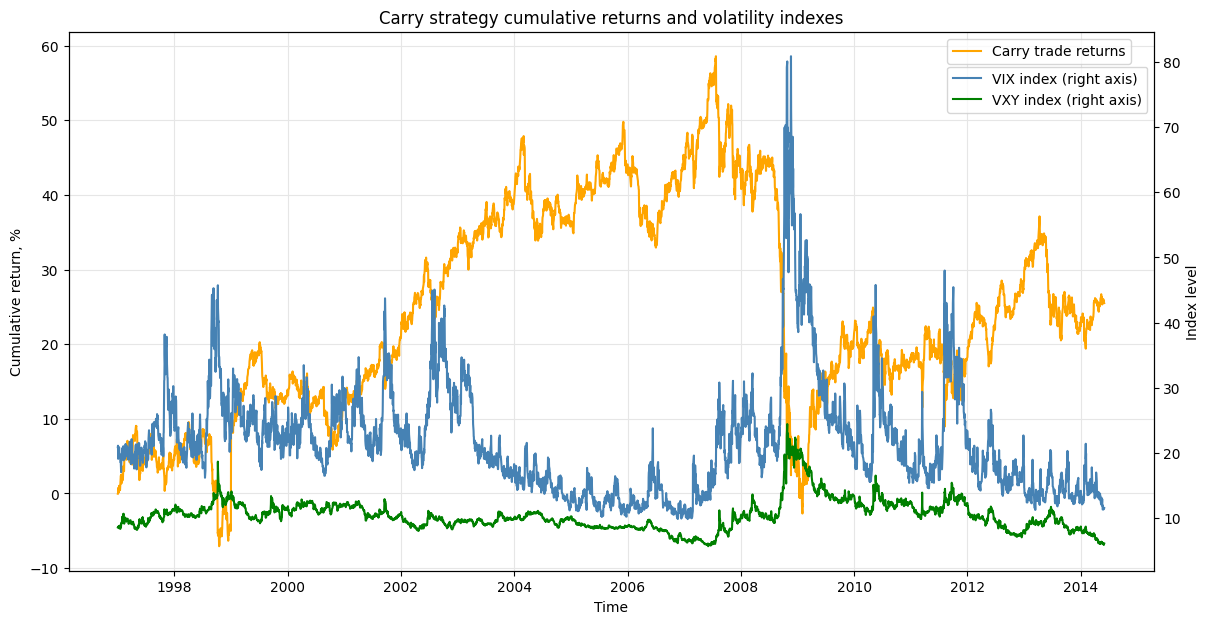

In [23]:
carry_cumrets = (SimpleCarry.carry_returns+1).cumprod()
new_vol = vol.copy()
new_vol = new_vol.reindex(carry_cumrets.index, method='ffill')
new_vol = new_vol.loc[carry_cumrets.index]

fig, ax = plt.subplots(figsize=(14, 7))
ax2 = ax.twinx()
ax.plot(carry_cumrets.index, carry_cumrets.values*100 -100, 
        color='orange', label='Carry trade returns')
ax2.plot(new_vol.index, new_vol.VIX, color='steelblue', label='VIX index (right axis)')
ax2.plot(new_vol.index, new_vol.VXY, color='green', label='VXY index (right axis)')
ax.legend(loc=(0.81, 0.94))
ax2.legend(loc=(0.81, 0.85))
ax.set_xlabel('Time')
ax.set_ylabel('Cumulative return, %')
ax2.set_ylabel('Index level')
ax.grid(color='0.9')
ax.set_title('Carry strategy cumulative returns and volatility indexes')

# сохраним картинку в классном разрешении, чтобы кайфовать
plt.savefig('images/figure 1.png', dpi=1200)
fig.show();